# Main Fig 4 — Iso-compute: Combined vs-total + Pareto

**Data**: `heatmap_df_test.csv` per task/head from `final_results/phase0_v3/inference/`  
**Tasks (main)**: 2 — sex classification, sleep efficiency  
**Head**: Transformer  
**Layout**: 1 row × 2 cols (1×2 subplots, `FULL_W` wide + right legend)  

Each panel overlays:  
- **Background** (faded, alpha≈0.20): all `(L, K)` vs-total curves, one colour per L  
- **Foreground** (opaque, lw=2.5): Pareto-optimal frontier, annotated with optimal L  

Two tasks chosen to contrast the two principal crossover regimes:  
- **(a) sex_binary** — budget-dependent crossover: short L + many K competitive at low budget,  
  long L dominates at ≥240 min  
- **(b) sleep_efficiency_binary** — context irreplaceable: long L Pareto-optimal at  
  virtually every budget; K cannot substitute  

Remaining tasks (age, apnea, bmi, depression, OSA) in supplementary.


In [1]:
%matplotlib inline

In [2]:
import sys
from pathlib import Path

# ── Workspace root: auto-detect by looking for final_results/ ─────────────────
def _find_workspace():
    """Walk up from CWD until we find a directory containing final_results/."""
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    # Explicit fallback (edit this if auto-detect fails)
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
FINAL_RESULTS  = WORKSPACE_ROOT / "final_results"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final_npj"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Add utils to path (notebooks/utils/)
_nb_dir = PAPER_FIGURES / "notebooks_npj"
sys.path.insert(0, str(_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS, BINARY_MAIN,
    HEAD_STYLE, TASK_LABEL, FONT_ANNOT, FONT_BASE, FONT_LABEL, FONT_TITLE,
)
from utils.data import set_root, load_analysis, load_heatmap, load_parquets
from utils import panels

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

# ── Confirm the workspace root is correct ─────────────────────────────────────
_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [3]:
# Panel labeling helper
def add_panel_label(ax, label, x=0.02, y=0.97):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="top", fontfamily="serif")

In [4]:
HEAD   = "transformer"
METRIC = "auroc"
ROW_H  = 2.8   # inches — single row; increase for more vertical space

# ── Main figure: 2 tasks showing contrasting iso-compute regimes ─────────────
# (a) sex_binary:               budget crossover — short L + many K at low budget,
#                               240m dominates at high budget (≥240 min)
# (b) sleep_efficiency_binary:  context irreplaceable — 240m Pareto-optimal at
#                               virtually every budget; K aggregation cannot substitute
TASKS = ["sex_binary", "sleep_efficiency_binary"]

hmaps = {t: load_heatmap("phase0_v3", t, HEAD) for t in TASKS}
print("Loaded:", {t: len(v) for t, v in hmaps.items()})


Loaded: {'sex_binary': 76, 'sleep_efficiency_binary': 85}


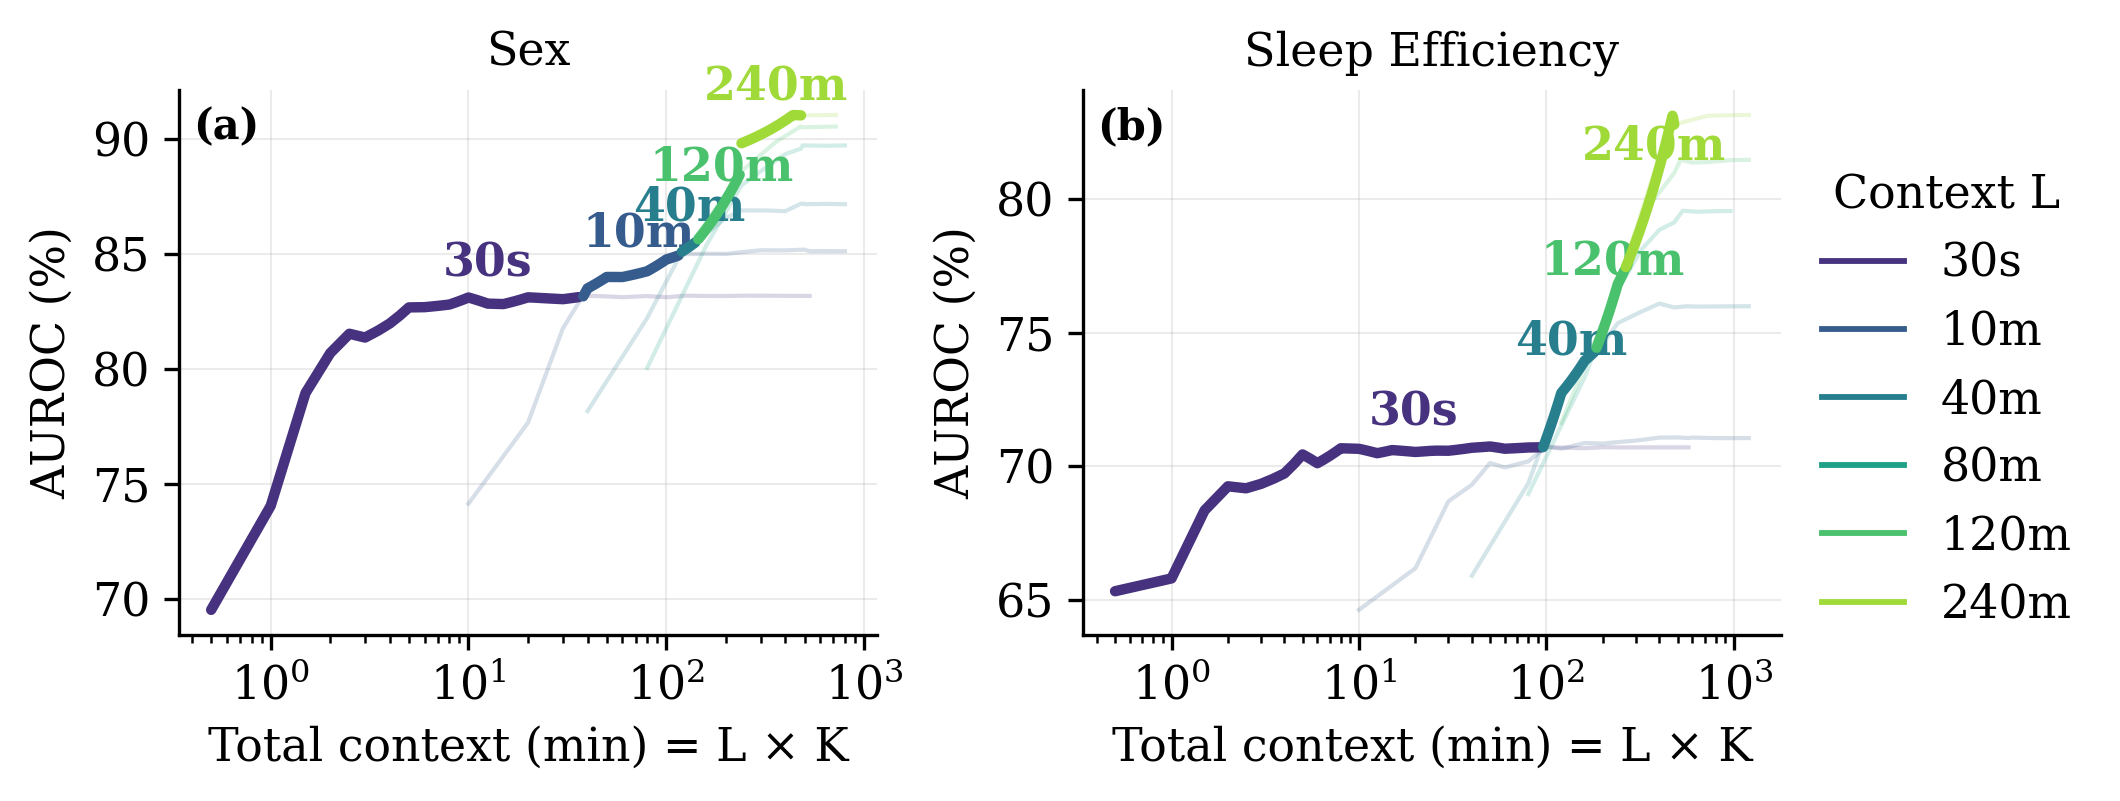

In [7]:
import matplotlib.lines as mlines

fig, axes = plt.subplots(1, 2, figsize=(FULL_W-1, ROW_H))

for i, (ax, task) in enumerate(zip(axes, TASKS)):
    panels.combined_iso_panel(ax, hmaps[task], col=METRIC)
    ax.set_title(TASK_LABEL[task], fontsize=FONT_TITLE)
    add_panel_label(ax, f"({chr(97+i)})")

# Shared legend: rebuild handles at alpha=1 from background lines in panel (a).
# combined_iso_panel labels background lines with ctx_lbl; we override alpha.
_raw_handles, _labels = axes[0].get_legend_handles_labels()
_handles = [mlines.Line2D([0], [0], color=h.get_color(), lw=1.4)
            for h in _raw_handles]
fig.legend(_handles, _labels,
           title="Context L", loc="center left",
           bbox_to_anchor=(1.0, 0.5),
           fontsize=FONT_BASE, title_fontsize=FONT_BASE,
           frameon=False, handlelength=1.8)

fig.tight_layout(w_pad=0.5)
fig.subplots_adjust(right=1)   # reserve space for the right-side legend
plt.show()


In [8]:
# ── Run when figure looks good ──────────────────────────────────
save_figure(fig, FINAL_OUT, "main_fig4_iso_main")
import shutil
shutil.copy(FINAL_OUT / "main_fig4_iso_main.pdf",
            WORKSPACE_ROOT / "npj_digital_medicine_submission" / "main_fig4_iso_main.pdf")
print("Saved + copied → npj_digital_medicine_submission/main_fig4_iso_main.pdf")

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final_npj/main_fig4_iso_main.pdf
Saved + copied → npj_digital_medicine_submission/main_fig4_iso_main.pdf


## ── SUPPLEMENTARY VERSION ─────────────────────────────────────────────────────

**Target:** `sfig_iso.pdf`  
**→ also copy to:** `npj_digital_medicine_submission/sfig_iso.pdf`  

Same combined panel (faded vs-total + opaque Pareto) for all remaining tasks:  
- **(a) age_class** — same budget-crossover pattern as sex  
- **(b) apnea_binary** — moderate L=80 min Pareto-optimal; neither extreme dominates  
- **(c) bmi_binary** — context-insensitive; Pareto frontier near-flat  
- **(d) depression_extreme_binary** — supplementary task  
- **(e) osa_binary_apples_postqc** — supplementary task (APPLES dataset only)  

> Uncomment all lines in the cell below and run to regenerate.

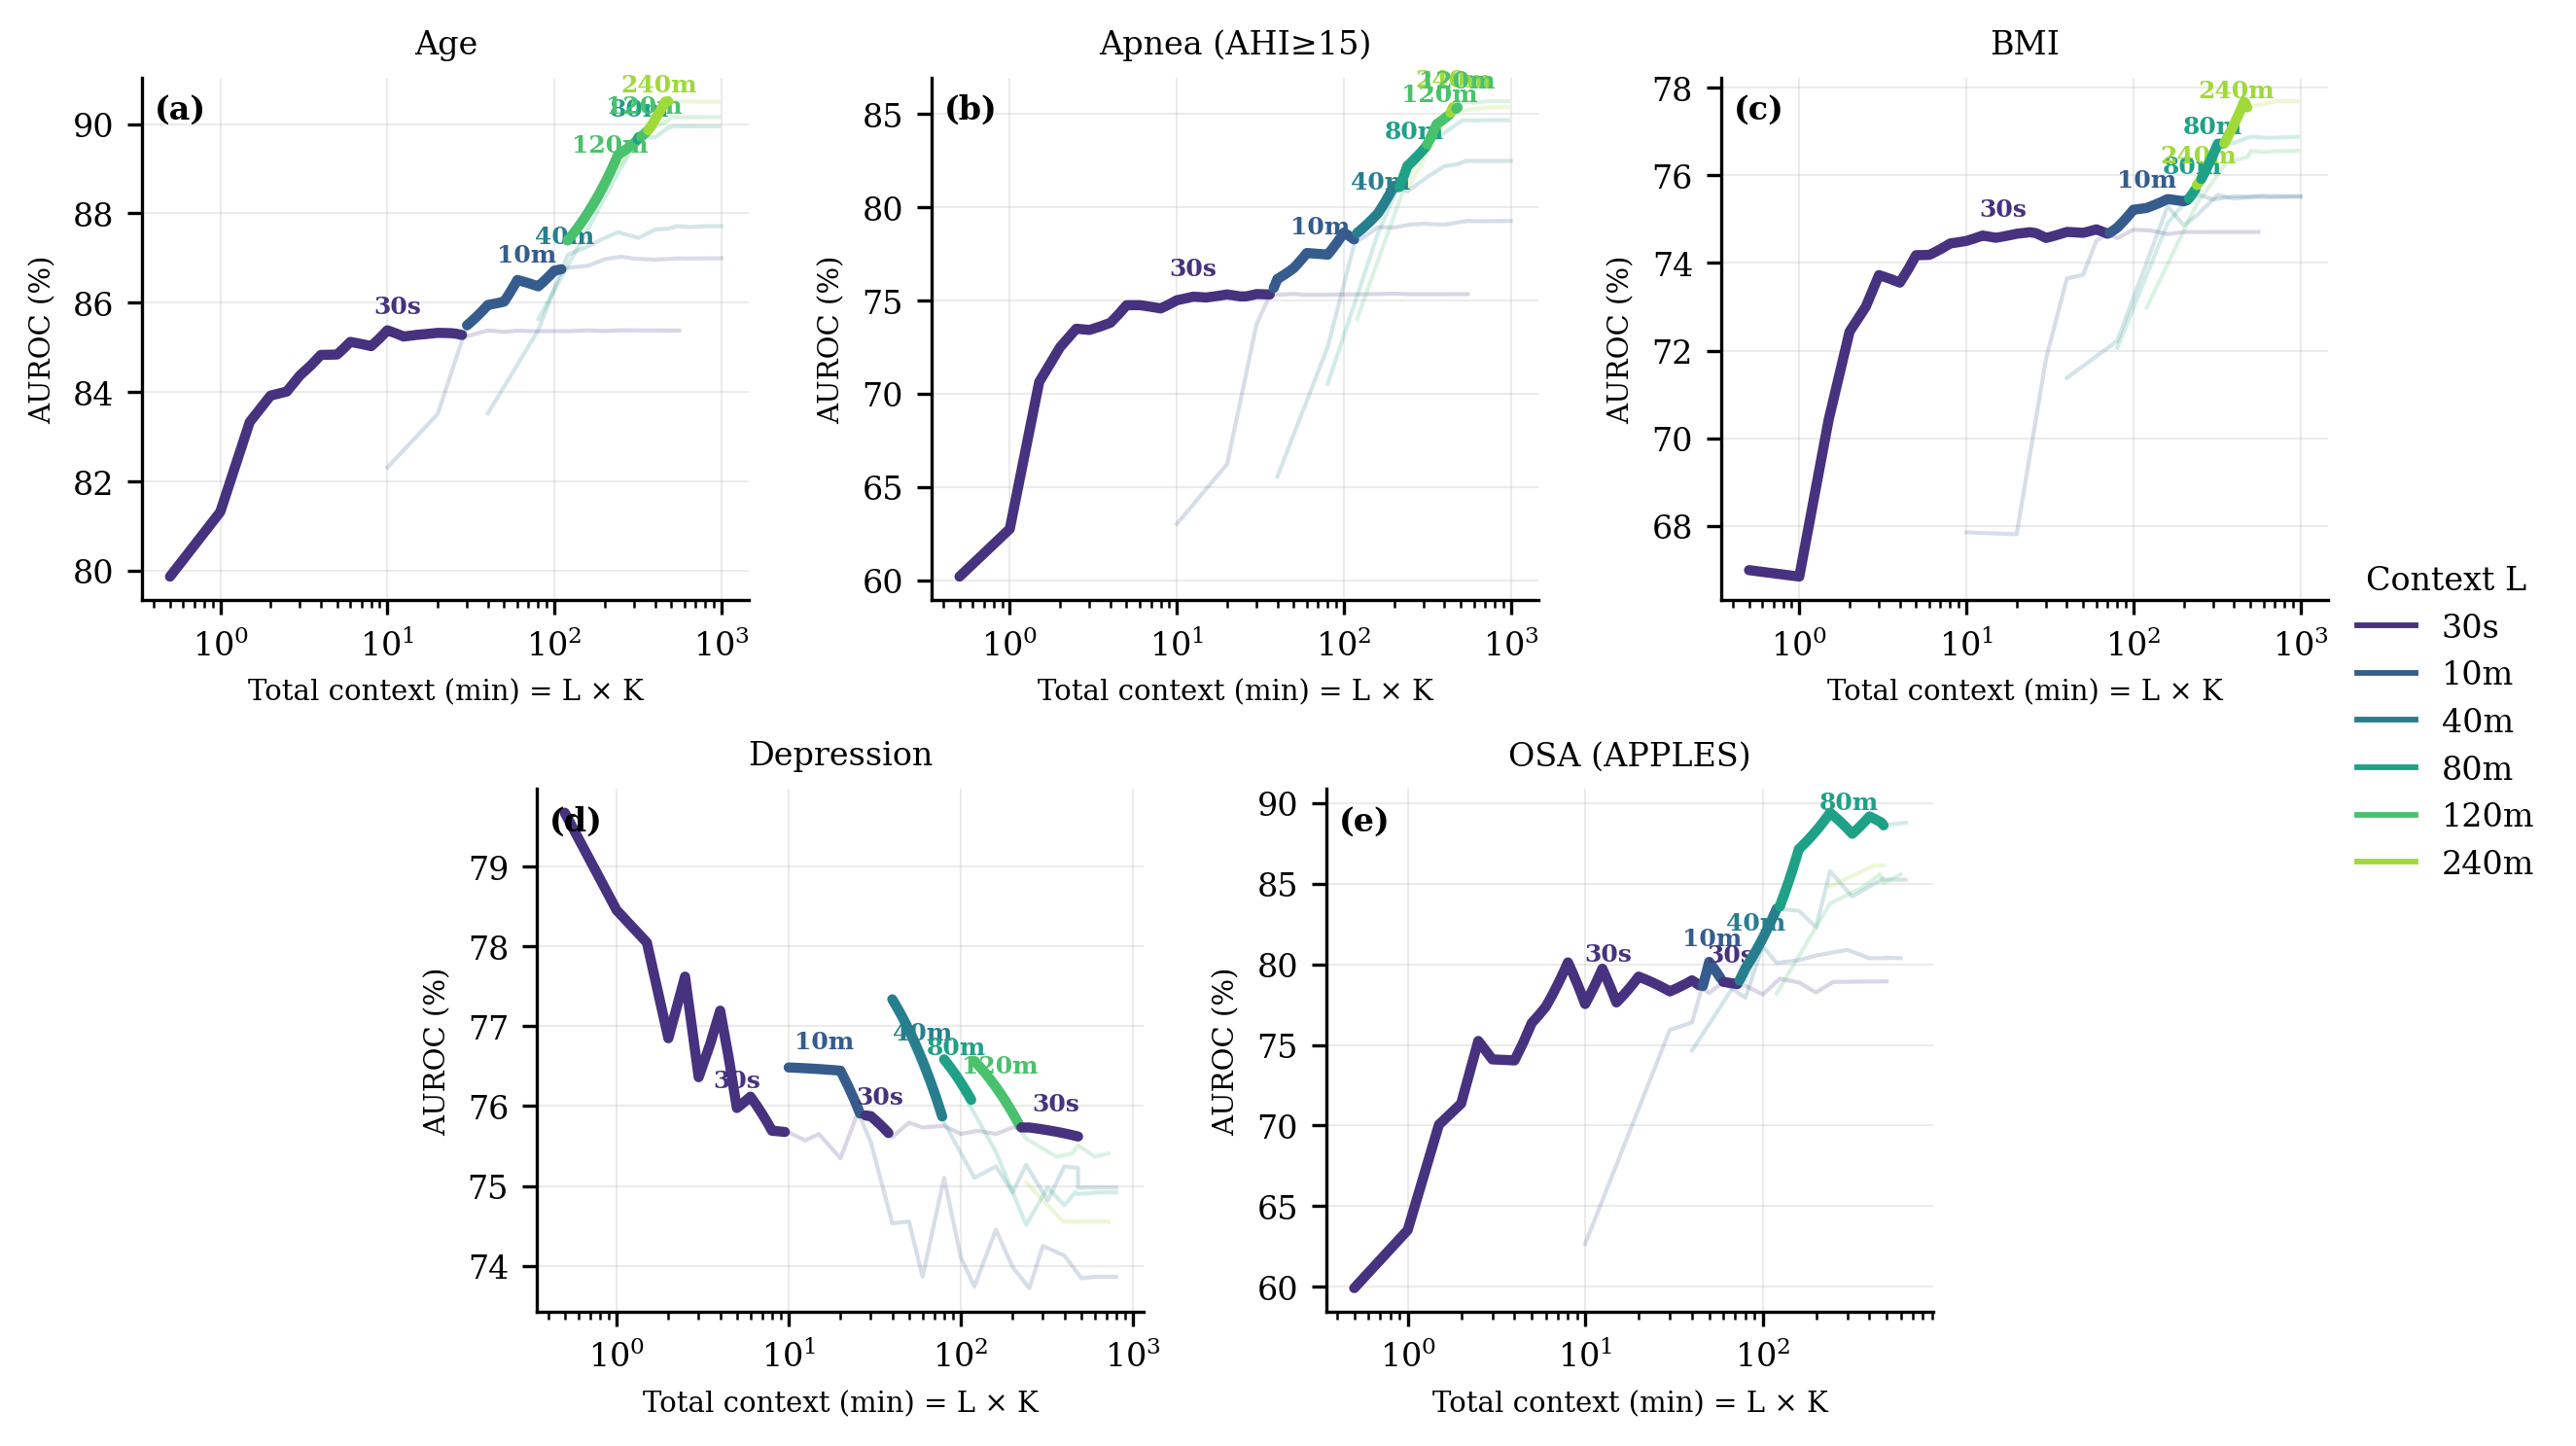

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# SUPPLEMENTARY  sfig_iso — combined iso-compute panel, remaining tasks
# Target: sfig_iso.pdf  (copy to npj_digital_medicine_submission/ when done)
# To regenerate: uncomment ALL lines below, then run this cell.
# ══════════════════════════════════════════════════════════════════════════════

_SUPP_ISO_TASKS = [
    "age_class",                  # same crossover as sex; moved to supp
    "apnea_binary",               # moderate L=80m optimal
    "bmi_binary",                 # context-insensitive, near-flat
    "depression_extreme_binary",
    "osa_binary_apples_postqc",
]
_SUPP_NCOLS = 3
_SUPP_ROW_H = 2.5
_SUPP_NROWS = (len(_SUPP_ISO_TASKS) + _SUPP_NCOLS - 1) // _SUPP_NCOLS

_supp_hmaps = {t: load_heatmap('phase0_v3', t, HEAD) for t in _SUPP_ISO_TASKS}

# 3+2 centred mosaic
_sl = [chr(97 + _i) for _i in range(len(_SUPP_ISO_TASKS))]
_n_last = len(_SUPP_ISO_TASKS) % _SUPP_NCOLS or _SUPP_NCOLS
_n_full  = len(_SUPP_ISO_TASKS) // _SUPP_NCOLS
_mosaic  = []
for _r in range(_n_full):
    _row = _sl[_r * _SUPP_NCOLS : (_r + 1) * _SUPP_NCOLS]
    _mosaic.append([lbl for lbl in _row for _ in range(2)])
if _n_last < _SUPP_NCOLS:
    _last = _sl[_n_full * _SUPP_NCOLS:]
    _pad  = _SUPP_NCOLS - _n_last
    _mosaic.append(['.'] * _pad +
                   [lbl for lbl in _last for _ in range(2)] +
                   ['.'] * _pad)

fig_supp, axd_supp = plt.subplot_mosaic(
    _mosaic, figsize=(FULL_W+1, _SUPP_NROWS * _SUPP_ROW_H)
)
for _i, (_lbl, _task) in enumerate(zip(_sl, _SUPP_ISO_TASKS)):
    panels.combined_iso_panel(axd_supp[_lbl], _supp_hmaps[_task], col=METRIC)
    axd_supp[_lbl].set_title(TASK_LABEL[_task], fontsize=FONT_TITLE)
    add_panel_label(axd_supp[_lbl], f'({chr(97+_i)})')
_raw_h, _lab = axd_supp[_sl[0]].get_legend_handles_labels()
_hnd = [mlines.Line2D([0], [0], color=h.get_color(), lw=1.4) for h in _raw_h]
fig_supp.legend(_hnd, _lab, title='Context L', loc='center left',
                bbox_to_anchor=(1.0, 0.5), fontsize=FONT_BASE,
                title_fontsize=FONT_BASE, frameon=False, handlelength=1.8)
fig_supp.tight_layout(w_pad=1.5)
fig_supp.subplots_adjust(right=1)
plt.show()


In [16]:
# Save and copy to npj_digital_medicine_submission
save_figure(fig_supp, FINAL_OUT, 'sfig_iso')
import shutil
_submission = WORKSPACE_ROOT / 'npj_digital_medicine_submission'
shutil.copy(FINAL_OUT / 'sfig_iso.pdf',
            _submission / 'sfig_iso.pdf')
print('Saved + copied → npj_digital_medicine_submission/sfig_iso.pdf')


  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/sfig_iso.pdf
Saved + copied → TBME_submission/sfig_iso.pdf
